# 1. Imports

In [1]:
import os, json, cv2, numpy as np, matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.transforms import functional as F

import albumentations as A # Library for augmentations

In [2]:
import sys
sys.path.append('pytorch_vision')

In [3]:
# from pytorch_vision import transforms, utils, engine, train
from utils import collate_fn
from engine import train_one_epoch, evaluate
from coco_utils import _coco_remove_images_without_annotations
import pycocotools

# 2. Augmentations

In [10]:
# def train_transform():
#     return A.Compose([
#         A.Sequential([
#             A.RandomRotate90(p=1), # Random rotation of an image by 90 degrees zero or more times
#             A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, brightness_by_max=True, always_apply=False, p=1), # Random change of brightness & contrast
#         ], p=1)
#     ],
#     keypoint_params=A.KeypointParams(format='xy', remove_invisible=False), # More about keypoint formats used in albumentations library read at https://albumentations.ai/docs/getting_started/keypoints_augmentation/
#     bbox_params=A.BboxParams(format='pascal_voc', label_fields=['bboxes_labels']) # Bboxes should have labels, read more here https://albumentations.ai/docs/getting_started/bounding_boxes_augmentation/
#     )

# def train_transform():
#     return A.Compose([
#         A.Sequential([
#             # Remove or reduce rotation probability for debugging
#             A.RandomRotate90(p=0),  # Reduce from p=1 to p=0.5 or p=0 for testing
#             A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, brightness_by_max=True, p=0.5),
#         ], p=1)
#     ],
#     keypoint_params=A.KeypointParams(format='xy', remove_invisible=False),
#     bbox_params=A.BboxParams(format='pascal_voc', label_fields=['bboxes_labels'])
#     )

def train_transform():
    return A.Compose([
        A.Sequential([
            A.Rotate(limit=45, p=0.3),  # Small rotations instead of 90° snaps
            A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, brightness_by_max=True, p=0.5),
            A.HorizontalFlip(p=0.3),  # Add horizontal flip
        ], p=1)
    ],
    keypoint_params=A.KeypointParams(format='xy', remove_invisible=False),
    bbox_params=A.BboxParams(format='pascal_voc', label_fields=['bboxes_labels'])
    )

# 3. Dataset class

In [48]:
class ClassDataset(Dataset):

    def __init__(self, root, transform=None, demo=False):                
        self.root = root
        self.transform = transform
        self.demo = demo # Use demo=True if you need transformed and original images (for example, for visualization purposes)
        self.imgs_files = sorted(os.listdir(os.path.join(root, "images")))
        self.ids = list(range(len(self.imgs_files)))  # Add this line for compatibility with COCO-style utilities
        # find the json annotations file
        self.annotations_file = [f for f in os.listdir(os.path.join(root, "annotations")) if f.endswith('.json')][0] # Assuming there is only one json file in the annotations folder       
        ann_path = os.path.join(self.root, "annotations", self.annotations_file)
        self.coco = pycocotools.coco.COCO(ann_path)
    
    def __getitem__(self, idx):
        import torch
        import cv2
        import json
        import numpy as np
        from torchvision.transforms import functional as F

        img_path = os.path.join(self.root, "images", self.imgs_files[idx])
        img_filename = self.imgs_files[idx]

        img_original = cv2.imread(img_path)
        img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)

        # ===== USE COCO API PROPERLY =====
        # Get all image IDs and find the one matching our filename
        img_ids = self.coco.getImgIds()
        
        # Find the correct image ID
        correct_img_id = None
        for img_id in img_ids:
            img_info = self.coco.loadImgs(img_id)[0]
            if img_info['file_name'] == img_filename:
                correct_img_id = img_id
                break
        
        if correct_img_id is None:
            print(f"ERROR: Could not find COCO image_id for {img_filename}")
            next_idx = (idx + 1) % len(self)
            return self.__getitem__(next_idx)
        
        # Get annotations for this image using COCO API
        ann_ids = self.coco.getAnnIds(imgIds=correct_img_id)
        annotations = self.coco.loadAnns(ann_ids)
        
        print(f"DEBUG: idx={idx}, filename={img_filename}, image_id={correct_img_id}, found {len(annotations)} annotations")
        
        if len(annotations) == 0:
            next_idx = (idx + 1) % len(self)
            return self.__getitem__(next_idx)
        
        # Extract data from COCO annotations
        bboxes_original = [ann['bbox'] for ann in annotations]
        keypoints_original = [ann['keypoints'] for ann in annotations]
        
        print(f"DEBUG: Keypoints from COCO API: {keypoints_original}")
        
        # Process keypoints: reshape from flat list [x,y,v] to nested format
        processed_keypoints = []
        for kp_flat in keypoints_original:
            # Reshape flat keypoint list into groups of 3 (x,y,v)
            kp_reshaped = []
            for i in range(0, len(kp_flat), 3):
                if i + 2 < len(kp_flat):
                    x, y, v = kp_flat[i], kp_flat[i+1], kp_flat[i+2]
                    kp_reshaped.append([x, y, v])
            processed_keypoints.append(kp_reshaped)
        
        keypoints_original = processed_keypoints

        # Filter out invalid keypoints
        valid_objects = []
        valid_bboxes = []
        valid_keypoints = []
        valid_categories = []
        
        for i, (bbox, kps, ann) in enumerate(zip(bboxes_original, keypoints_original, annotations)):
            # Check if keypoints are valid
            if len(kps) > 0 and kps[0][0] >= 0 and kps[0][1] >= 0:
                valid_bboxes.append(bbox)
                valid_keypoints.append(kps)
                valid_categories.append(ann['category_id'])
        
        if len(valid_bboxes) == 0:
            next_idx = (idx + 1) % len(self)
            return self.__getitem__(next_idx)

        # Convert bboxes from [xmin, ymin, w, h] to [xmin, ymin, xmax, ymax]
        bboxes_original = [
            [bbox[0], bbox[1], bbox[0] + bbox[2], bbox[1] + bbox[3]]
            for bbox in valid_bboxes
        ]
        
        keypoints_original = valid_keypoints

        # Create labels for bboxes (needed for albumentations)
        labels_dict = {1: 'angle_bar', 2: 'round_bar', 3: 'flat_bar'}
        bboxes_labels_original = [labels_dict.get(cat_id, 'object') for cat_id in valid_categories]

        if self.transform:
            keypoints_original_flattened = [kp[0][:2] for kp in keypoints_original if len(kp) > 0]
            try:
                transformed = self.transform(
                    image=img_original,
                    bboxes=bboxes_original,
                    bboxes_labels=bboxes_labels_original,
                    keypoints=keypoints_original_flattened
                )
                img = transformed['image']
                bboxes = transformed['bboxes']
                img_h, img_w = img.shape[:2]
                keypoints = []
                for kp in transformed['keypoints']:
                    x, y = kp[0], kp[1]
                    v = 2
                    if not (0 <= x < img_w and 0 <= y < img_h):
                        x, y, v = 0, 0, 0
                    keypoints.append([[x, y, v]])
            except Exception as e:
                print(f"Transform failed: {e}")
                img = img_original
                bboxes = bboxes_original
                keypoints = [[[kp[0][0], kp[0][1], kp[0][2]]] for kp in keypoints_original]
        else:
            img, bboxes, keypoints = img_original, bboxes_original, keypoints_original

        # Convert to torch tensors
        bboxes = torch.as_tensor(bboxes, dtype=torch.float32)
        if bboxes.numel() == 0:
            bboxes = bboxes.new_zeros((0, 4))
        elif bboxes.ndim == 1:
            bboxes = bboxes.unsqueeze(0)

        num_keypoints = 1  # Set this to your actual number of keypoints per object
        keypoints = torch.as_tensor(keypoints, dtype=torch.float32)
        if keypoints.numel() == 0:
            keypoints = keypoints.new_zeros((0, num_keypoints, 3))
        
        # Create target dictionary
        target = {}
        target["boxes"] = bboxes
        labels_tensor = torch.as_tensor([1 for _ in range(bboxes.shape[0])], dtype=torch.int64)
        if labels_tensor.numel() == 0:
            labels_tensor = labels_tensor.new_zeros((0,), dtype=torch.int64)
        target["labels"] = labels_tensor
        target["keypoints"] = keypoints
        if bboxes.shape[0] == 0 or bboxes.shape[1] < 4:
            target["area"] = torch.as_tensor([], dtype=torch.float32)
        else:
            target["area"] = (bboxes[:, 3] - bboxes[:, 1]) * (bboxes[:, 2] - bboxes[:, 0])
        target["image_id"] = torch.tensor([idx])
        target["iscrowd"] = torch.zeros(bboxes.shape[0], dtype=torch.int64)
        img = F.to_tensor(img)

        # For original targets (for demo/visualization)
        bboxes_original = torch.as_tensor(bboxes_original, dtype=torch.float32)
        if bboxes_original.numel() == 0:
            bboxes_original = bboxes_original.new_zeros((0, 4))
        elif bboxes_original.ndim == 1:
            bboxes_original = bboxes_original.unsqueeze(0)
        target_original = {}
        target_original["boxes"] = bboxes_original
        labels_original = torch.as_tensor([1 for _ in range(bboxes_original.shape[0])], dtype=torch.int64)
        if labels_original.numel() == 0:
            labels_original = labels_original.new_zeros((0,), dtype=torch.int64)
        target_original["labels"] = labels_original
        keypoints_original_tensor = torch.as_tensor(keypoints_original, dtype=torch.float32)
        if keypoints_original_tensor.numel() == 0:
            keypoints_original_tensor = keypoints_original_tensor.new_zeros((0, num_keypoints, 3))
        target_original["keypoints"] = keypoints_original_tensor
        target_original["image_id"] = torch.tensor([idx])
        if bboxes_original.shape[0] == 0 or bboxes_original.shape[1] < 4:
            target_original["area"] = torch.as_tensor([], dtype=torch.float32)
        else:
            target_original["area"] = (bboxes_original[:, 3] - bboxes_original[:, 1]) * (bboxes_original[:, 2] - bboxes_original[:, 0])
        target_original["iscrowd"] = torch.zeros(bboxes_original.shape[0], dtype=torch.int64)
        img_original = F.to_tensor(img_original)

        if self.demo:
            return img, target, img_original, target_original
        else:
            return img, target
    
    def __len__(self):
        return len(self.imgs_files)

# 4. Visualizing a random item from dataset

In [51]:
KEYPOINTS_FOLDER_TRAIN = '.\\datasets\\bars_keypoints_v3\\'
dataset = ClassDataset(KEYPOINTS_FOLDER_TRAIN, transform=train_transform(), demo=True)
data_loader = DataLoader(dataset, batch_size=1, shuffle=True, collate_fn=collate_fn)

iterator = iter(data_loader)
batch = next(iterator)

print("Original targets:\n", batch[3], "\n\n")
print("Transformed targets:\n", batch[1])

loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
DEBUG: idx=262, filename=00263.png, image_id=241, found 49 annotations
DEBUG: Keypoints from COCO API: [[806, 716, 2], [834, 610, 2], [917, 589, 2], [994, 445, 2], [1152, 511, 2], [1276, 494, 2], [816, 457, 2], [1047, 401, 2], [1186, 430, 2], [948, 643, 2], [1078, 657, 2], [1190, 590, 2], [876, 664, 2], [1031, 710, 2], [1128, 622, 2], [701, 732, 2], [926, 685, 2], [1032, 562, 2], [1252, 642, 2], [993, 650, 2], [1093, 562, 2], [749, 661, 2], [957, 627, 2], [1069, 532, 2], [1299, 633, 2], [882, 632, 2], [1008, 569, 2], [1184, 638, 2], [792, 674, 2], [1040, 498, 2], [1258, 516, 2], [846, 571, 2], [970, 474, 2], [1161, 562, 2], [692, 671, 2], [886, 492, 2], [1129, 553, 2], [1358, 599, 2], [785, 618, 2], [1212, 527, 2], [637, 660, 2], [886, 397, 2], [1085, 518, 2], [1260, 488, 2], [825, 535, 2], [985, 414, 2], [1180, 489, 2], [584, 649, 2], [904, 353, 2]]
Original targets:
 ({'boxes': tensor([[ 744.,  569.,  

Raw batch keypoints: [[[ 806.  716.    2.]]

 [[ 834.  610.    2.]]

 [[ 917.  589.    2.]]

 [[ 994.  445.    2.]]

 [[1152.  511.    2.]]

 [[1276.  494.    2.]]

 [[ 816.  457.    2.]]

 [[1047.  401.    2.]]

 [[1186.  430.    2.]]

 [[ 948.  643.    2.]]

 [[1078.  657.    2.]]

 [[1190.  590.    2.]]

 [[ 876.  664.    2.]]

 [[1031.  710.    2.]]

 [[1128.  622.    2.]]

 [[ 701.  732.    2.]]

 [[ 926.  685.    2.]]

 [[1032.  562.    2.]]

 [[1252.  642.    2.]]

 [[ 993.  650.    2.]]

 [[1093.  562.    2.]]

 [[ 749.  661.    2.]]

 [[ 957.  627.    2.]]

 [[1069.  532.    2.]]

 [[1299.  633.    2.]]

 [[ 882.  632.    2.]]

 [[1008.  569.    2.]]

 [[1184.  638.    2.]]

 [[ 792.  674.    2.]]

 [[1040.  498.    2.]]

 [[1258.  516.    2.]]

 [[ 846.  571.    2.]]

 [[ 970.  474.    2.]]

 [[1161.  562.    2.]]

 [[ 692.  671.    2.]]

 [[ 886.  492.    2.]]

 [[1129.  553.    2.]]

 [[1358.  599.    2.]]

 [[ 785.  618.    2.]]

 [[1212.  527.    2.]]

 [[ 637.  660.    2

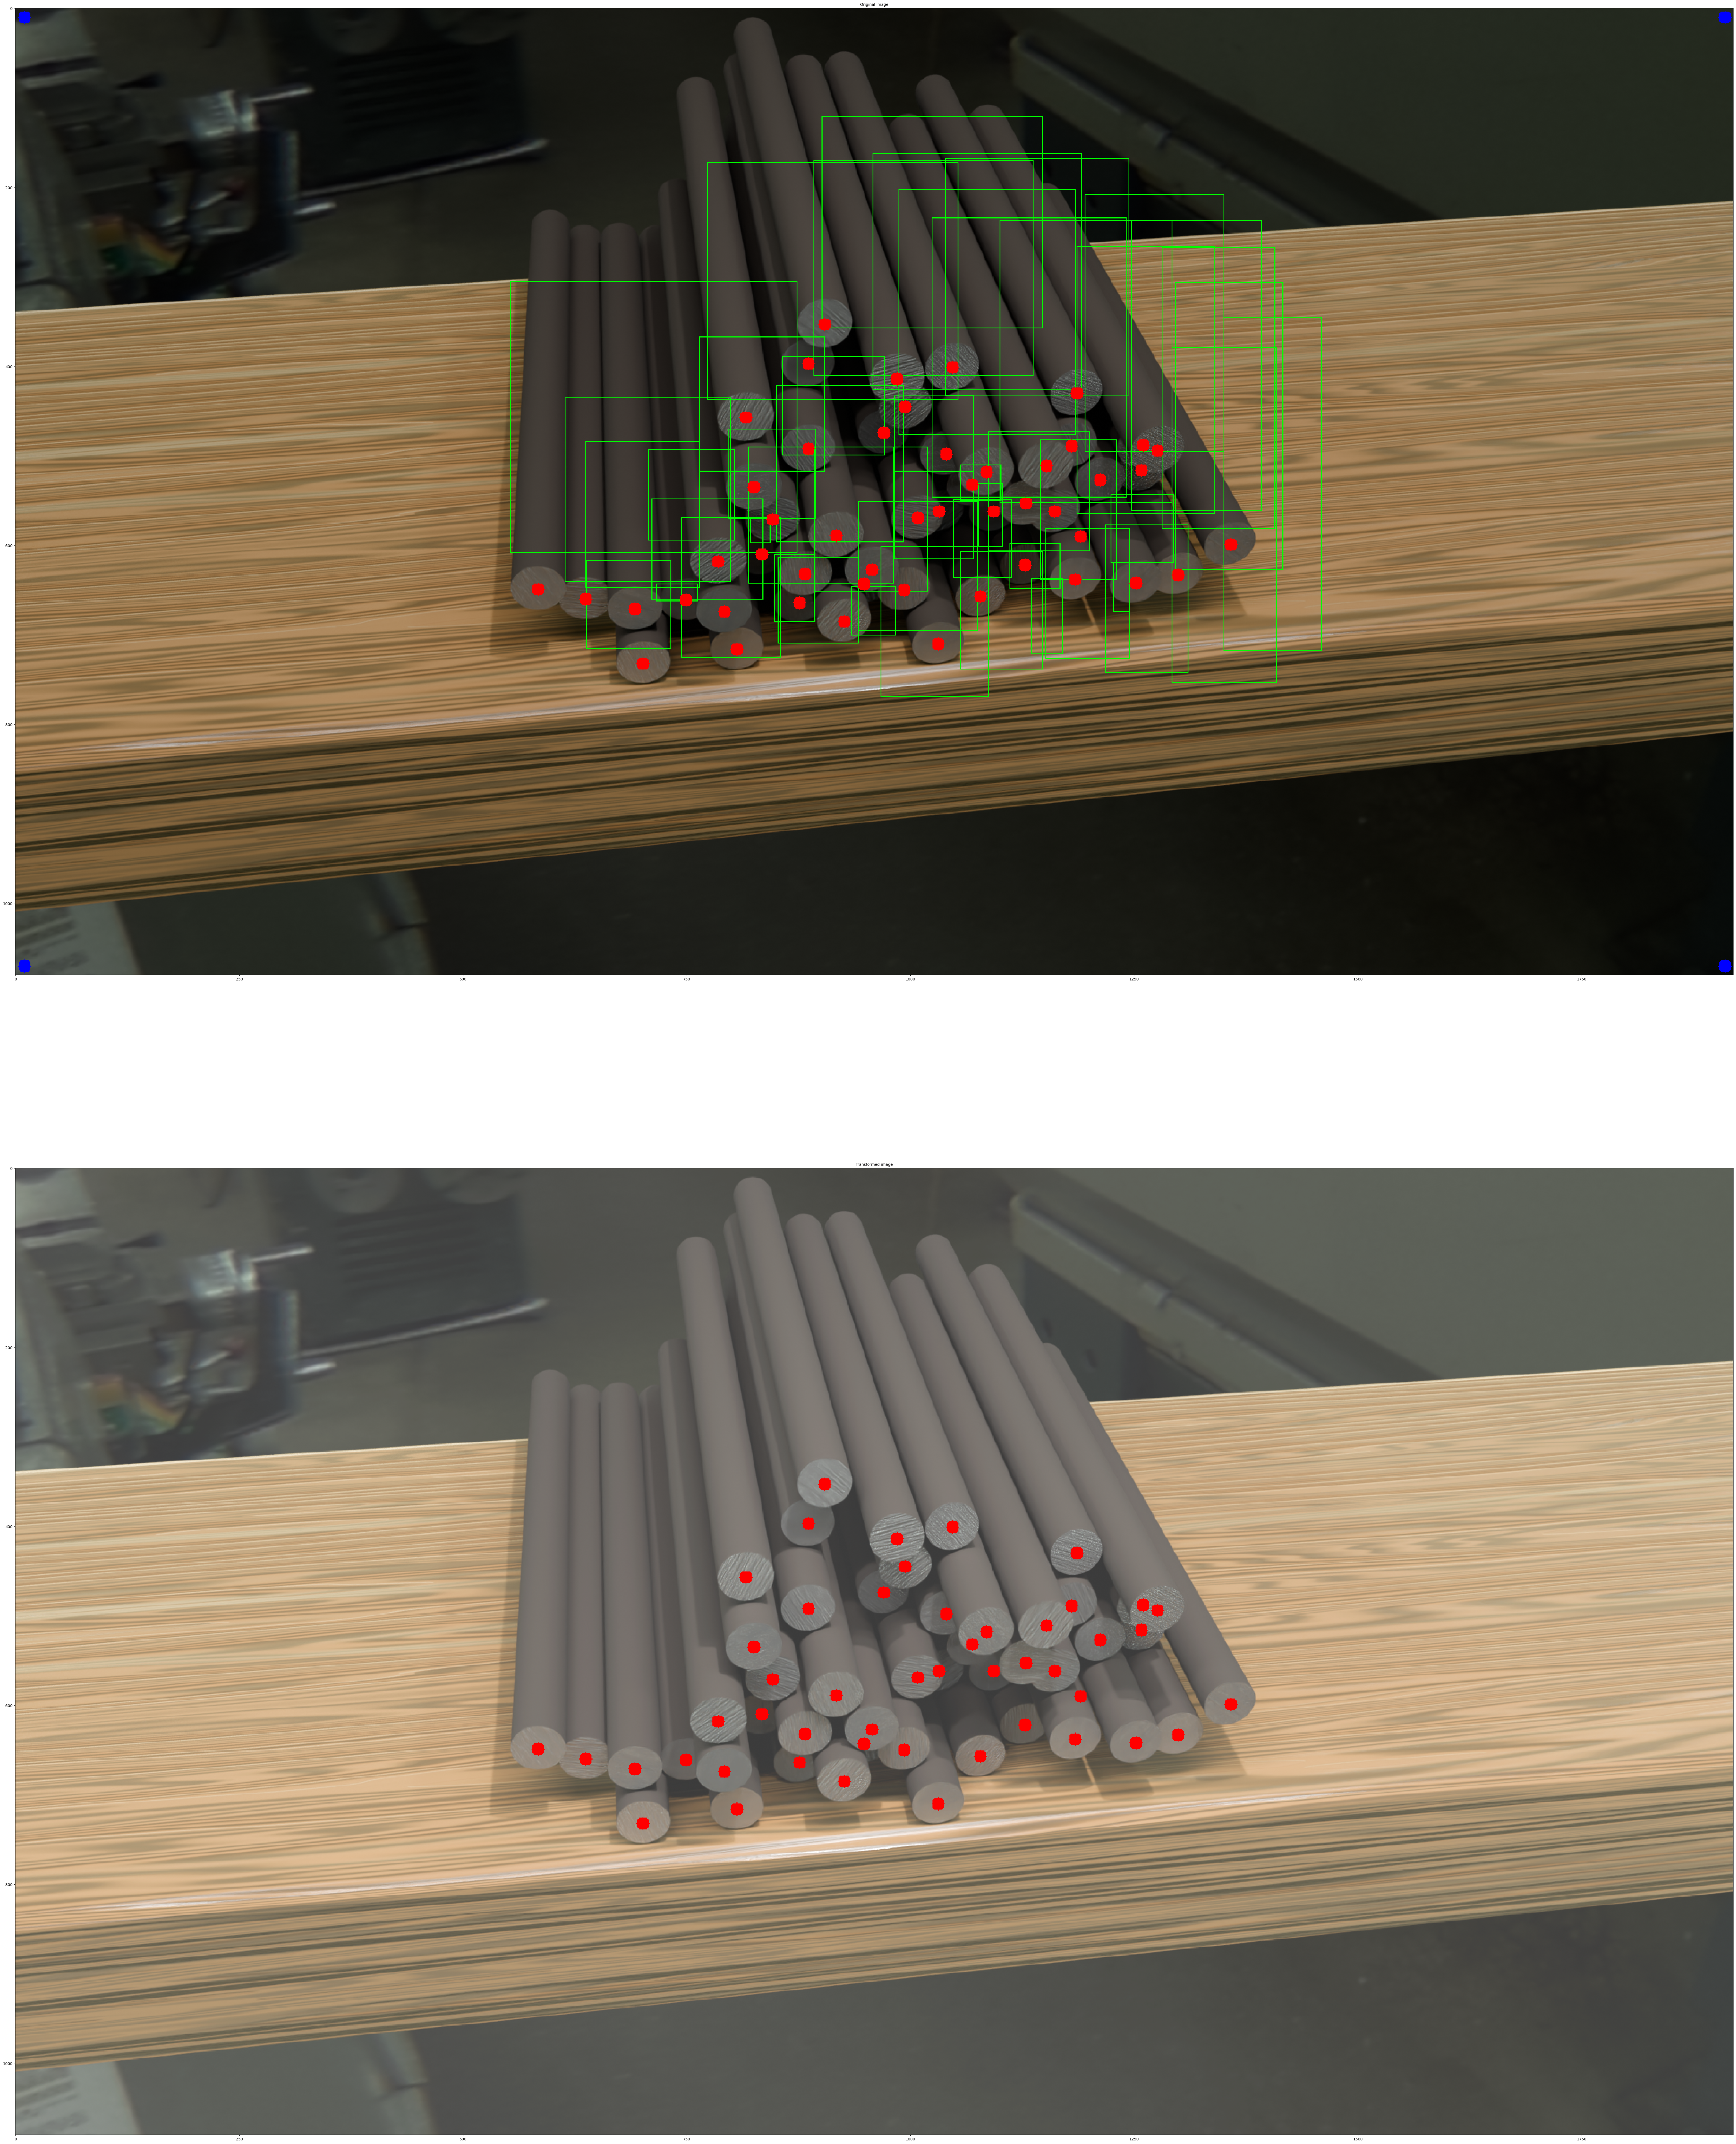

In [52]:
keypoints_classes_ids2names = {0: 'center'}

def visualize(image, bboxes, keypoints, image_original=None, bboxes_original=None, keypoints_original=None, fig_size=200):
    fontsize = 10

    for bbox in bboxes:
        start_point = (bbox[0], bbox[1])
        end_point = (bbox[2], bbox[3])
        # image = cv2.rectangle(image.copy(), start_point, end_point, (0,255,0), 1)
    
    for kps in keypoints:
        for idx, kp in enumerate(kps):
            image = cv2.circle(image.copy(), tuple(kp), 2, (255,0,0), 10)
            # image = cv2.putText(image.copy(), " " + keypoints_classes_ids2names[idx], tuple(kp), cv2.FONT_HERSHEY_SIMPLEX, .5, (255,0,0), 3, cv2.LINE_AA)

    if image_original is None and keypoints_original is None:
        plt.figure(figsize=(fig_size,fig_size))
        plt.imshow(image)

    else:
        for bbox in bboxes_original:
            start_point = (bbox[0], bbox[1])
            end_point = (bbox[2], bbox[3])
            image_original = cv2.rectangle(image_original.copy(), start_point, end_point, (0,255,0), 1)
        
        for kps in keypoints_original:
            for idx, kp in enumerate(kps):
                image_original = cv2.circle(image_original, tuple(kp), 2, (255,0,0), 10)
                # image_original = cv2.putText(image_original, " " + keypoints_classes_ids2names[idx], tuple(kp), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255,0,0), 3, cv2.LINE_AA)

        image_original = cv2.circle(image_original, (10,10), 2, (0,0,255), 10)
        image_original = cv2.circle(image_original, (10,1070), 2, (0,0,255), 10)
        image_original = cv2.circle(image_original, (1910,10), 2, (0,0,255), 10)
        image_original = cv2.circle(image_original, (1910,1070), 2, (0,0,255), 10)


        f, ax = plt.subplots(2,1, figsize=(fig_size, fig_size/2))

        ax[0].imshow(image_original)
        ax[0].set_title('Original image', fontsize=fontsize)

        ax[1].imshow(image)
        ax[1].set_title('Transformed image', fontsize=fontsize)


        
image = (batch[0][0].permute(1,2,0).numpy() * 255).astype(np.uint8)
bboxes = batch[1][0]['boxes'].detach().cpu().numpy().astype(np.int32).tolist()

'''
keypoints = []
# print debugging information about keypoints
print("batch",batch[1][0]['keypoints'].detach().cpu().numpy().astype(np.int32).tolist())

# for kps in batch[1][0]['keypoints'].detach().cpu().numpy().astype(np.int32).tolist():
for kps in np.round(batch[1][0]['keypoints'].detach().cpu().numpy()).astype(np.int32).tolist():
    # If kps is a flat list (not a list of lists), wrap it in a list
    if isinstance(kps[0], (int, float)):
        keypoints.append([kps[:2]])
    else:
        keypoints.append([kp[:2] for kp in kps])
    # keypoints.append([kp[:2] for kp in kps])
'''

keypoints = []
print("Raw batch keypoints:", batch[1][0]['keypoints'].detach().cpu().numpy())

for kps in batch[1][0]['keypoints'].detach().cpu().numpy().astype(np.int32).tolist():
    print(f"Processing keypoints: {kps}")
    if isinstance(kps[0], (int, float)):
        keypoints.append([kps[:2]])
        print(f"Added as single: {[kps[:2]]}")
    else:
        keypoints.append([kp[:2] for kp in kps])
        print(f"Added as multiple: {[kp[:2] for kp in kps]}")

print(f"Final keypoints for visualization: {keypoints}")

image_original = (batch[2][0].permute(1,2,0).numpy() * 255).astype(np.uint8)
bboxes_original = batch[3][0]['boxes'].detach().cpu().numpy().astype(np.int32).tolist()

keypoints_original = []
for kps in batch[3][0]['keypoints'].detach().cpu().numpy().astype(np.int32).tolist():
    if isinstance(kps[0], (int, float)):
        keypoints_original.append([kps[:2]])
    else:
        keypoints_original.append([kp[:2] for kp in kps])


visualize(image, bboxes, keypoints, image_original, bboxes_original, keypoints_original)


print(f"Tensor image shape: {batch[0][0].shape}")
print(f"Numpy image shape: {image.shape}")
print(f"Original tensor shape: {batch[2][0].shape}")
print(f"Original numpy shape: {image_original.shape}")
print(f"Keypoints: {keypoints}")
print(f"Original keypoints: {keypoints_original}")

# 5. Training

In [53]:
def get_model(num_keypoints, weights_path=None):
    
    anchor_generator = AnchorGenerator(sizes=(32, 64, 128, 256, 512), aspect_ratios=(0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0))
    model = torchvision.models.detection.keypointrcnn_resnet50_fpn(pretrained=False,
                                                                   pretrained_backbone=True,
                                                                   num_keypoints=num_keypoints,
                                                                   num_classes = 3, # Background is the first class, object is the second class
                                                                   rpn_anchor_generator=anchor_generator)

    if weights_path:
        state_dict = torch.load(weights_path)
        model.load_state_dict(state_dict)        
        
    return model

In [54]:
def safe_evaluate(model, data_loader, device):
    """
    A safe wrapper around the evaluate function that handles empty keypoint tensors.
    """
    try:
        evaluate(model, data_loader, device)
    except RuntimeError as e:
        if "zero-size" in str(e) or "shape" in str(e) and "keypoints" in str(e):
            print("Warning: Evaluation failed due to empty keypoints. Continuing training...")
        else:
            # Re-raise if it's not the keypoints error
            raise e

In [55]:
def custom_evaluate(model, data_loader, device):
    """
    A simple custom evaluation function that skips COCO API completely.
    This just computes validation loss without any metrics.
    """
    model.eval()
    
    # Metrics to track
    total_loss = 0
    total_keypoint_loss = 0
    total_box_loss = 0
    num_batches = 0
    
    # Don't compute gradients during evaluation
    with torch.no_grad():
        for images, targets in data_loader:
            try:
                # Move data to the right device
                images = list(img.to(device) for img in images)
                targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
                
                # Get model losses
                loss_dict = model(images, targets)
                
                # # Sum up losses
                # # Check if loss_dict is a dictionary or a list
                # if isinstance(loss_dict, dict):
                #     # If it's a dictionary, sum the values
                #     losses = sum(loss for loss in loss_dict.values())
                    
                #     # Track specific losses if available
                #     if 'loss_keypoint' in loss_dict:
                #         total_keypoint_loss += loss_dict['loss_keypoint'].item()
                #     if 'loss_box_reg' in loss_dict:
                #         total_box_loss += loss_dict['loss_box_reg'].item()
                # else:
                #     # If it's a list, sum the elements directly
                #     losses = sum(loss_dict)
                        
                #     # Since we don't have named losses in a list, we can't track specific ones
                #     # You might need to modify this based on the actual structure
                #     # Or create a more robust way to identify specific loss types
                    
                losses = sum(loss_dict)
                    
                # total_loss += losses.item()
                total_loss += losses

                # Track specific losses if available
                if 'loss_keypoint' in loss_dict:
                    total_keypoint_loss += loss_dict['loss_keypoint'].item()
                if 'loss_box_reg' in loss_dict:
                    total_box_loss += loss_dict['loss_box_reg'].item()
                    
                num_batches += 1
            except Exception as e:
                print(f"Skipping batch due to: {e}")
                continue
    
    # Calculate average losses
    if num_batches > 0:
        avg_loss = total_loss / num_batches
        avg_keypoint_loss = total_keypoint_loss / num_batches if total_keypoint_loss > 0 else 0
        avg_box_loss = total_box_loss / num_batches if total_box_loss > 0 else 0
        
        print(f"Validation - Total Loss: {avg_loss:.4f}, Keypoint Loss: {avg_keypoint_loss:.4f}, Box Loss: {avg_box_loss:.4f}")
    else:
        print("No valid batches for evaluation.")
    
    return total_loss / max(num_batches, 1)  # Return average loss

In [56]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

KEYPOINTS_FOLDER_TRAIN = '.\\datasets\\bars_keypoints_v2\\'
KEYPOINTS_FOLDER_TEST = '.\\datasets\\bars_keypoints_v2\\'

dataset_train = ClassDataset(KEYPOINTS_FOLDER_TRAIN, transform=train_transform(), demo=False)
# dataset_train = ClassDataset(KEYPOINTS_FOLDER_TRAIN, transform=None, demo=False)
dataset_test = ClassDataset(KEYPOINTS_FOLDER_TEST, transform=None, demo=False)

# Remove images without annotations
dataset_train = _coco_remove_images_without_annotations(dataset_train)
# Remove images without annotations
dataset_test = _coco_remove_images_without_annotations(dataset_test)

data_loader_train = DataLoader(dataset_train, batch_size=3, shuffle=True, collate_fn=collate_fn)
data_loader_test = DataLoader(dataset_test, batch_size=1, shuffle=False, collate_fn=collate_fn)

model = get_model(num_keypoints = 1)
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.001, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.3)
num_epochs = 5

for epoch in range(num_epochs):
    train_one_epoch(model, optimizer, data_loader_train, device, epoch, print_freq=1000)
    lr_scheduler.step()
    # evaluate(model, data_loader_test, device)
    # safe_evaluate(model, data_loader_test, device)  # Use our safe wrapper
    # custom_evaluate(model, data_loader_test, device)  # Use our custom evaluation function
    print(f"Epoch {epoch+1}/{num_epochs} completed.")
    
# Save model weights after training
torch.save(model.state_dict(), 'keypointsrcnn_weights_v2.pth')

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


c:\Users\FLRZ01\OneDrive - SMS group GmbH\Desktop\dev\tagger\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\FLRZ01\OneDrive - SMS group GmbH\Desktop\dev\tagger\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
c:\Users\FLRZ01\OneDrive - SMS group GmbH\Desktop\dev\tagger\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained_backbone' is deprecated since 0.13 and may be removed in the future, please use 'weights_backbone' instead.
  warnings.warn(
c:\Users\FLRZ01\OneDrive - SMS group GmbH\Desktop\dev\tagger\venv\Lib\site-packages\torchvision\models\_utils.py:223: Use

DEBUG: idx=10, filename=00011.png, image_id=11, found 49 annotations
DEBUG: Keypoints from COCO API: [[530, 655, 2], [419, 511, 2], [360, 404, 2], [302, 328, 2], [307, 235, 2], [544, 275, 2], [760, 293, 2], [978, 258, 2], [1199, 259, 2], [640, 677, 2], [836, 666, 2], [1006, 616, 2], [1233, 622, 2], [1322, 592, 2], [476, 592, 2], [731, 633, 2], [932, 653, 2], [1126, 614, 2], [1268, 526, 2], [605, 597, 2], [803, 563, 2], [1001, 550, 2], [1187, 542, 2], [1377, 516, 2], [522, 491, 2], [705, 561, 2], [909, 563, 2], [1084, 539, 2], [1316, 455, 2], [611, 444, 2], [796, 465, 2], [1003, 461, 2], [1203, 443, 2], [1422, 445, 2], [468, 411, 2], [704, 400, 2], [881, 436, 2], [1080, 443, 2], [1336, 364, 2], [557, 359, 2], [809, 356, 2], [998, 338, 2], [1195, 344, 2], [1458, 366, 2], [414, 346, 2], [665, 341, 2], [902, 342, 2], [1123, 367, 2], [1302, 253, 2]]
DEBUG: idx=9, filename=00010.png, image_id=10, found 49 annotations
DEBUG: Keypoints from COCO API: [[526, 644, 2], [411, 497, 2], [360, 389, 2

c:\Users\FLRZ01\OneDrive - SMS group GmbH\Desktop\dev\tagger\pytorch_vision\engine.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):


Epoch: [0]  [ 0/35]  eta: 0:43:02  lr: 0.000030  loss: 10.1963 (10.1963)  loss_classifier: 1.1651 (1.1651)  loss_box_reg: 0.1526 (0.1526)  loss_keypoint: 8.0237 (8.0237)  loss_objectness: 0.7002 (0.7002)  loss_rpn_box_reg: 0.1547 (0.1547)  time: 73.7792  data: 0.3260
DEBUG: idx=29, filename=00030.png, image_id=30, found 49 annotations
DEBUG: Keypoints from COCO API: [[20, 720, 2], [-9, 658, 2], [-1, 565, 2], [-49, 530, 2], [-79, 476, 2], [327, 389, 2], [643, 405, 2], [958, 421, 2], [1283, 431, 2], [347, 697, 2], [656, 699, 2], [962, 710, 2], [1272, 724, 2], [1600, 729, 2], [152, 559, 2], [485, 542, 2], [795, 572, 2], [1120, 563, 2], [1439, 538, 2], [331, 634, 2], [646, 642, 2], [956, 671, 2], [1275, 664, 2], [1638, 699, 2], [147, 478, 2], [475, 474, 2], [800, 477, 2], [1122, 471, 2], [1449, 488, 2], [331, 550, 2], [652, 548, 2], [962, 555, 2], [1274, 547, 2], [1644, 594, 2], [156, 383, 2], [466, 402, 2], [792, 416, 2], [1124, 390, 2], [1449, 394, 2], [338, 458, 2], [646, 481, 2], [963,

# 6. Visualizing model predictions

In [ ]:
iterator = iter(data_loader_test)

In [ ]:
%%capture
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

model = get_model(num_keypoints=1)
model.load_state_dict(torch.load('keypointsrcnn_weights.pth', map_location=device))
model.to(device)
model.eval()

In [ ]:
batch = next(iterator)
if isinstance(batch, tuple) and len(batch) == 2:
    # Normal case: (images, targets)
    images, targets = batch
elif isinstance(batch, tuple) and len(batch) == 4:
    # Demo case: (images, targets, original_images, original_targets)
    images, targets, _, _ = batch
else:
    # Fallback
    print(f"Unexpected batch format: {type(batch)}, length: {len(batch) if isinstance(batch, tuple) else 'N/A'}")
    images, targets = batch[0], batch[1]

with torch.no_grad():
    model.to(device)
    model.eval()
    output = model(images)

print("Predictions: \n", output)

In [ ]:
image = (images[0].permute(1,2,0).detach().cpu().numpy() * 255).astype(np.uint8)

In [ ]:
scores = output[0]['scores'].detach().cpu().numpy()

keypoints = []
bboxes = []

# Only process if we have any detections
if len(scores) > 0:
    high_scores_idxs = np.where(scores > 0.3)[0].tolist()  # Lower threshold for early training
    
    if len(high_scores_idxs) > 0:
        try:
            post_nms_idxs = torchvision.ops.nms(
                output[0]['boxes'][high_scores_idxs], 
                output[0]['scores'][high_scores_idxs], 
                0.3
            ).cpu().numpy()
            
            if len(post_nms_idxs) > 0:
                for kps in output[0]['keypoints'][high_scores_idxs][post_nms_idxs].detach().cpu().numpy():
                    keypoints.append([list(map(int, kp[:2])) for kp in kps])
                    
                for bbox in output[0]['boxes'][high_scores_idxs][post_nms_idxs].detach().cpu().numpy():
                    bboxes.append(list(map(int, bbox.tolist())))
        except Exception as e:
            print(f"Warning: Visualization error: {e}")

# block box plotting
bboxes = []


visualize(image, bboxes, keypoints)